In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

In [2]:
# loading the dataset

df_path = r"..\data\interim\location_data.csv"

df = pd.read_csv(df_path,chunksize=100000)

df

In [3]:
num_chunks = 0

df = pd.read_csv(df_path,chunksize=100000)
for df_chunk in df:
    num_chunks += 1

num_chunks

333

In [4]:
# sampling

all_samples = []

df = pd.read_csv(df_path,chunksize=100000)
for df_chunk in df:
    all_samples.append(df_chunk.sample(500))

all_samples

[       pickup_latitude  pickup_longitude
 93971        40.733002        -74.003212
 92503        40.740368        -73.979195
 22770        40.763000        -73.969704
 69786        40.746632        -73.993622
 56863        40.782421        -73.971191
 ...                ...               ...
 95534        40.792046        -73.964432
 85846        40.771141        -73.956589
 45685        40.762455        -73.978737
 69515        40.726868        -73.979950
 80568        40.721371        -73.844345
 
 [500 rows x 2 columns],
         pickup_latitude  pickup_longitude
 199588        40.762272        -73.960381
 132317        40.733337        -73.987648
 162294        40.779377        -73.950569
 140498        40.721958        -73.985687
 178240        40.744156        -73.976265
 ...                 ...               ...
 119894        40.777031        -73.989098
 175217        40.767590        -73.953819
 164651        40.744564        -73.989166
 155499        40.707836        -73.931

In [5]:
len(all_samples)

333

In [6]:
all_samples[0]

,pickup_latitude,pickup_longitude
93971,40.733002,-74.003212
92503,40.740368,-73.979195
22770,40.763000,-73.969704
69786,40.746632,-73.993622
56863,40.782421,-73.971191
...,...,...
95534,40.792046,-73.964432
85846,40.771141,-73.956589
45685,40.762455,-73.978737
69515,40.726868,-73.979950


In [7]:
sample_df = pd.concat(all_samples,axis=0)

sample_df

,pickup_latitude,pickup_longitude
93971,40.733002,-74.003212
92503,40.740368,-73.979195
22770,40.763000,-73.969704
69786,40.746632,-73.993622
56863,40.782421,-73.971191
...,...,...
33228122,40.704269,-74.012062
33210313,40.761883,-73.986465
33230792,40.749176,-73.975632
33232260,40.829086,-73.948616


In [8]:
sample_df.shape

(166500, 2)

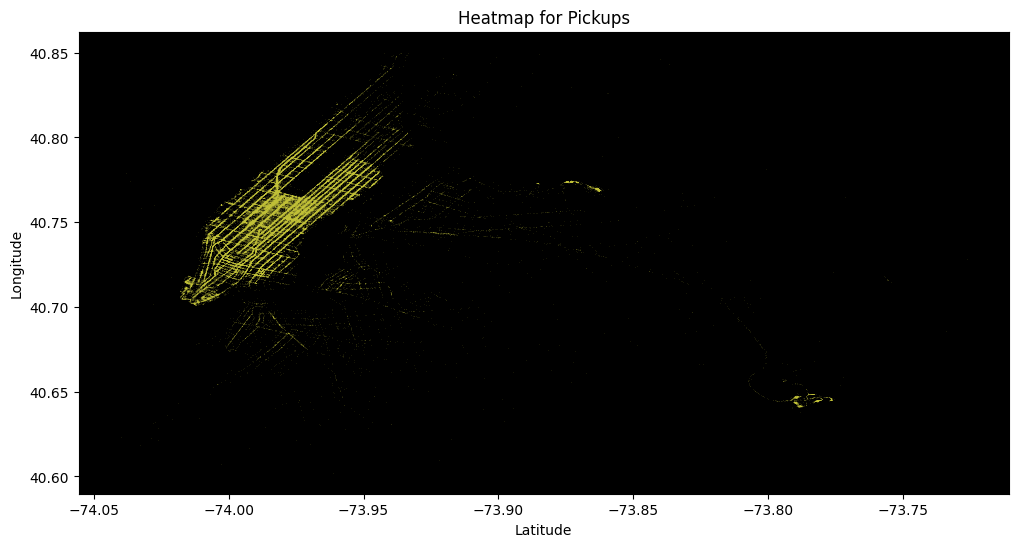

In [30]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(12,6))
ax.set_facecolor('k')
sns.scatterplot(y=sample_df['pickup_latitude'],x=sample_df['pickup_longitude'],ax=ax,s=0.05,c='y')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
plt.show()

In [19]:
# setting output as pandas dataframe
set_config(transform_output='pandas')


In [21]:
# scaling the data

# object creation
scaler = StandardScaler()

# fit and transfrom
scaled_sample_df = scaler.fit_transform(sample_df)

scaled_sample_df

,pickup_latitude,pickup_longitude
93971,-0.667599,-0.794894
92503,-0.396034,-0.139513
22770,0.438348,0.119475
69786,-0.165113,-0.533200
56863,1.154317,0.078878
...,...,...
33228122,-1.726855,-1.036394
33210313,0.397143,-0.337918
33230792,-0.071310,-0.042289
33232260,2.874695,0.694911


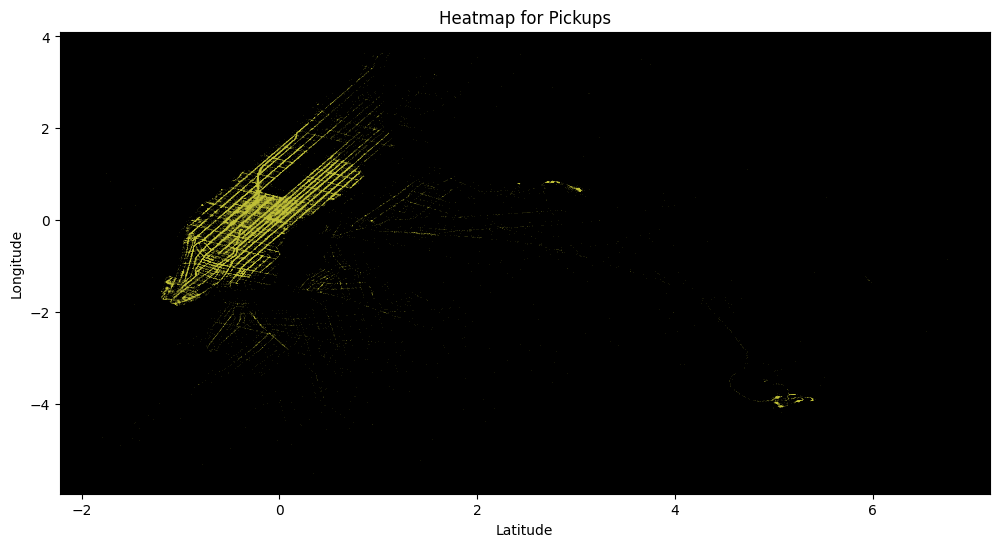

In [29]:
# sactter plot for scaled data

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(12,6))
ax.set_facecolor('k')
sns.scatterplot(y=scaled_sample_df['pickup_latitude'],x=scaled_sample_df['pickup_longitude'],ax=ax,s=0.05,c='y')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
plt.show()

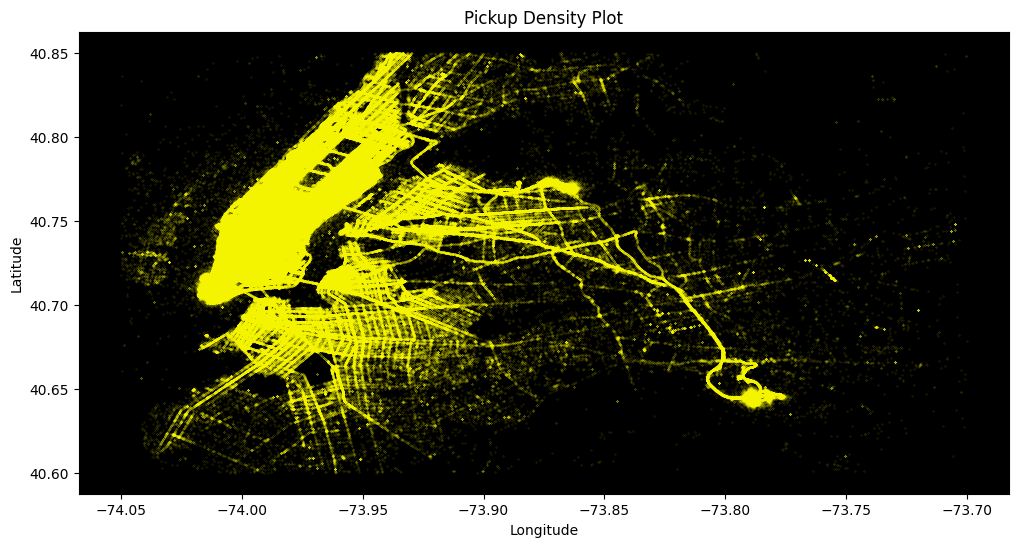

In [ ]:
# on complete dataset

df_iter = pd.read_csv(df_path, chunksize=100000)

fig, ax = plt.subplots(figsize=(12,6))
ax.set_facecolor('black')

ax.set_title('Pickup Density Plot')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

for chunk in df_iter:
    ax.scatter(
        chunk['pickup_longitude'],
        chunk['pickup_latitude'],
        s=0.05,
        color='yellow',
        alpha=0.3
    )

plt.show()

In [31]:
# fit on scaler

df_iter = pd.read_csv(df_path, chunksize=100000)

scaler = StandardScaler()

for chunk in df_iter:
    scaler.partial_fit(chunk)

scaler

,copy,True
,with_mean,True
,with_std,True


In [32]:
# complete dataset mean and std

print("The mean of the complete dataset is",scaler.mean_)
print("The standard deviation of the complete dataset is",scaler.scale_)

The mean of the complete dataset is [ 40.75107121 -73.9740618 ]
The standard deviation of the complete dataset is [0.02722268 0.03675237]


In [33]:
def haversine_distance(lat1:float, lon1:float, lat2:float, lon2:float):
    """
    Calculate haversine distances between two points given their latitude and
    longitude coordinates
    """
    
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    
    earth_radius = 3958.8
    distance = earth_radius * c
    return distance

In [67]:
def select_optimum_k(k_values:list):

    # looping over list of k_values
    for k in k_values:

        df_iter = pd.read_csv(df_path,chunksize=100000)
        mini_batch = MiniBatchKMeans(n_clusters=k,init='k-means++',max_iter=100,batch_size=1024,random_state=42,n_init='auto')

        for chunk in df_iter:

            # scale the chunk
            scaled_chunk = scaler.transform(chunk)

            # partial train the model
            mini_batch.partial_fit(scaled_chunk)

        # centroid values
        cluster_centre_scaled = mini_batch.cluster_centers_
        cluster_centre = scaler.inverse_transform(cluster_centre_scaled)

        # calculate distance
        all_distance = []

        for i in cluster_centre:
            distances = []

            for j in cluster_centre:
                distance = haversine_distance(i[0],i[1],j[0],j[1])
                distances.append(float(distance))

            all_distance.append(distances)

        all_distance = np.array(all_distance)

        # sort array
        sorted_distance = np.sort(all_distance,axis=1)

        # nearby region
        region_count = 8

        # selected distances
        selected_distance = sorted_distance[:,1:region_count+1]

        # average distance
        avg_distance = selected_distance.mean(axis=1)

        # count average that fits the criteria
        counter = ((avg_distance>=1.0) & (avg_distance<=1.5)).sum()
        percentage = ((avg_distance>=1.0) & (avg_distance<=1.5)).mean()

        print(f"For {k} clusters, the number of nearby regions that fits criteria are {counter} and is {percentage * 100:.1f}% regions of total")

In [68]:
possible_k_values = np.arange(10,100,10)

possible_k_values

array([10, 20, 30, 40, 50, 60, 70, 80, 90])

In [69]:
# passing different values of k to find the optimum k

select_optimum_k(possible_k_values)

For 10 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 20 clusters, the number of nearby regions that fits criteria are 6 and is 30.0% regions of total
For 30 clusters, the number of nearby regions that fits criteria are 9 and is 30.0% regions of total
For 40 clusters, the number of nearby regions that fits criteria are 8 and is 20.0% regions of total
For 50 clusters, the number of nearby regions that fits criteria are 7 and is 14.0% regions of total
For 60 clusters, the number of nearby regions that fits criteria are 10 and is 16.7% regions of total
For 70 clusters, the number of nearby regions that fits criteria are 13 and is 18.6% regions of total
For 80 clusters, the number of nearby regions that fits criteria are 14 and is 17.5% regions of total
For 90 clusters, the number of nearby regions that fits criteria are 17 and is 18.9% regions of total


In [70]:
df_iter = pd.read_csv(df_path,chunksize=100000)
mini_batch = MiniBatchKMeans(n_clusters=30,init='k-means++',max_iter=100,batch_size=1024,n_init='auto')

for chunk in df_iter:

    # scale the chunk
    scaled_chunk = scaler.transform(chunk)

    # train the model
    mini_batch.partial_fit(scaled_chunk)

# centroid values
centroids = mini_batch.cluster_centers_

In [76]:
mini_batch

,n_clusters,30
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,None
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


In [71]:
centroids

array([[ 1.94066466,  0.48324319],
       [-0.73614041, -0.76062338],
       [ 0.37525778, -0.12174738],
       [-3.84564599,  5.15478462],
       [-3.04785662,  0.25676802],
       [ 0.56931876,  1.46910093],
       [ 0.21808418, -0.39938921],
       [ 0.82267739,  0.33160197],
       [-0.12641807, -0.45704175],
       [-1.03099075, -0.44103948],
       [-1.58429853, -0.99449074],
       [-1.3174111 ,  0.52297659],
       [ 0.77727129,  0.57528881],
       [-0.31570526, -0.76364039],
       [-0.08511619,  1.18568648],
       [-0.45348781,  2.69523604],
       [ 2.70221993,  0.84984079],
       [ 1.16211107, -0.10268893],
       [ 0.32951291, -0.6404501 ],
       [-1.2056441 , -0.89107347],
       [ 1.16999185,  0.58727909],
       [ 1.56008283,  0.11073073],
       [ 0.69151473, -0.27401061],
       [-0.60604465, -0.34860807],
       [ 0.76872898,  2.85473733],
       [ 0.10833411,  0.01553617],
       [-2.10074   ,  1.26867229],
       [ 0.43599746,  0.23130113],
       [-0.21228539,

In [72]:
centroids_org = scaler.inverse_transform(centroids)

centroids_org

array([[ 40.8039013 , -73.95630147],
       [ 40.7310315 , -74.00201651],
       [ 40.76128673, -73.97853631],
       [ 40.64638244, -73.78461125],
       [ 40.6681004 , -73.96462497],
       [ 40.76656959, -73.92006886],
       [ 40.75700805, -73.9887403 ],
       [ 40.77346669, -73.96187464],
       [ 40.74762977, -73.99085917],
       [ 40.72300489, -73.99027105],
       [ 40.70794237, -74.01061169],
       [ 40.71520776, -73.95484117],
       [ 40.77223062, -73.95291858],
       [ 40.74247687, -74.0021274 ],
       [ 40.74875412, -73.93048501],
       [ 40.73872606, -73.87500549],
       [ 40.82463287, -73.94282814],
       [ 40.78270698, -73.97783586],
       [ 40.76004143, -73.99759986],
       [ 40.71825035, -74.00681086],
       [ 40.78292152, -73.9524779 ],
       [ 40.79354084, -73.96999219],
       [ 40.76989609, -73.98413234],
       [ 40.73457305, -73.98687398],
       [ 40.77199807, -73.86914344],
       [ 40.75402036, -73.97349081],
       [ 40.69388345, -73.92743509],
 

In [75]:
centroids.shape

(30, 2)

In [77]:
# perform prediction and assign cluster
sample_prediction = mini_batch.predict(scaled_sample_df)

sample_prediction

array([ 1, 28, 27, ..., 28, 16,  1], shape=(166500,), dtype=int32)

In [78]:
sample_prediction.shape

(166500,)

In [81]:
np.unique(sample_prediction)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], dtype=int32)

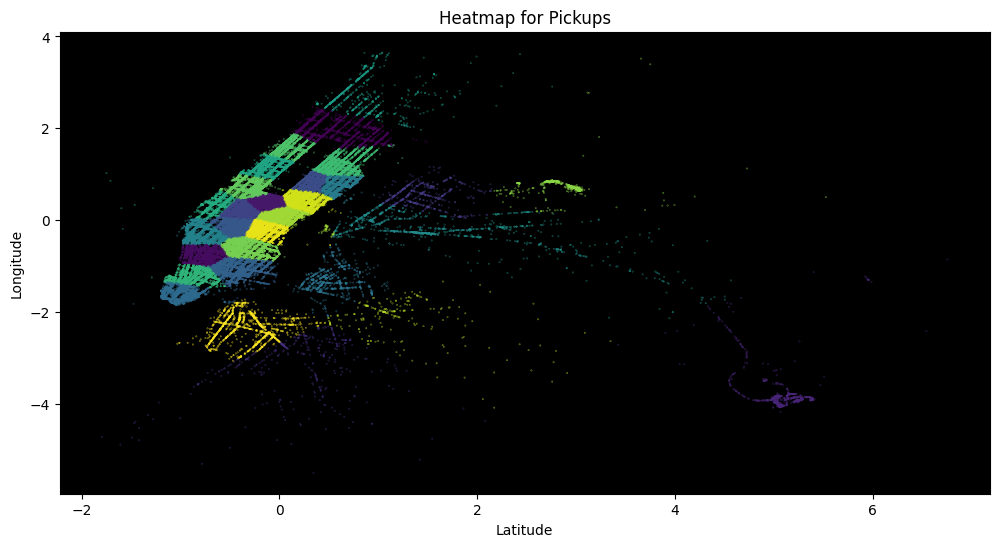

In [82]:
# plot the dataset on a scatter plot

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(12,6))

ax.set_facecolor('k')
ax.scatter(scaled_sample_df['pickup_longitude'],scaled_sample_df['pickup_latitude'],s=0.05,c=sample_prediction)
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

plt.show()